# 04 CRNN Training

This notebook walks through training the CRNN (Convolutional-Recurrent) OCR model on the extracted ground-truth line crops.
The model uses a CNN backbone to extract visual features and a bidirectional LSTM to decode character sequences via CTC loss.
Rare characters (diacritics, ligatures specific to Spanish renaissance print) receive higher weight in the loss via inverse-frequency weighting.


In [7]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import matplotlib.pyplot as plt

from src.crnn_model import build_vocab, compute_char_weights, CRNN
from src.utils import read_jsonl

GROUND_TRUTH_FILE = ROOT / 'data' / 'ground_truth' / 'ground_truth.jsonl'
CROP_DIR = ROOT / 'data' / 'crops'
OUTPUT_DIR = ROOT / 'outputs' / 'crnn'


## 1. Build vocabulary and compute character weights

We first collect all characters that appear in the ground truth and compute their frequency.
Rare characters (e.g. ñ, ü, period-specific abbreviations) get **higher** weight in the CTC loss,
which forces the model to pay more attention to them during training.


In [8]:
records = read_jsonl(GROUND_TRUTH_FILE)
texts = [r['text'] for r in records]
vocab = build_vocab(texts)
weights = compute_char_weights(texts, vocab)

print(f'Vocabulary size: {len(vocab)} characters')
print(f'Sample entries: {dict(list(vocab.items())[:10])}')

# Show the top 15 highest-weighted (rarest) characters
sorted_weights = sorted(
    [(ch, weights[idx].item()) for ch, idx in vocab.items()],
    key=lambda x: -x[1]
)[:15]
print('\nRarest characters (highest CTC weight):')
for ch, w in sorted_weights:
    print(f'  {repr(ch):12s}  weight={w:.3f}')


Vocabulary size: 67 characters
Sample entries: {'<BLANK>': 0, '\n': 1, ' ': 2, '!': 3, '&': 4, '(': 5, ')': 6, ',': 7, '-': 8, '.': 9}

Rarest characters (highest CTC weight):
  '!'           weight=4.226
  '('           weight=4.226
  ')'           weight=4.226
  '0'           weight=4.226
  '6'           weight=4.226
  'H'           weight=4.226
  'Q'           weight=4.226
  'Ñ'           weight=4.226
  '&'           weight=2.817
  '1'           weight=2.817
  'é'           weight=2.817
  'í'           weight=2.817
  'J'           weight=2.113
  'Y'           weight=2.113
  'ó'           weight=2.113


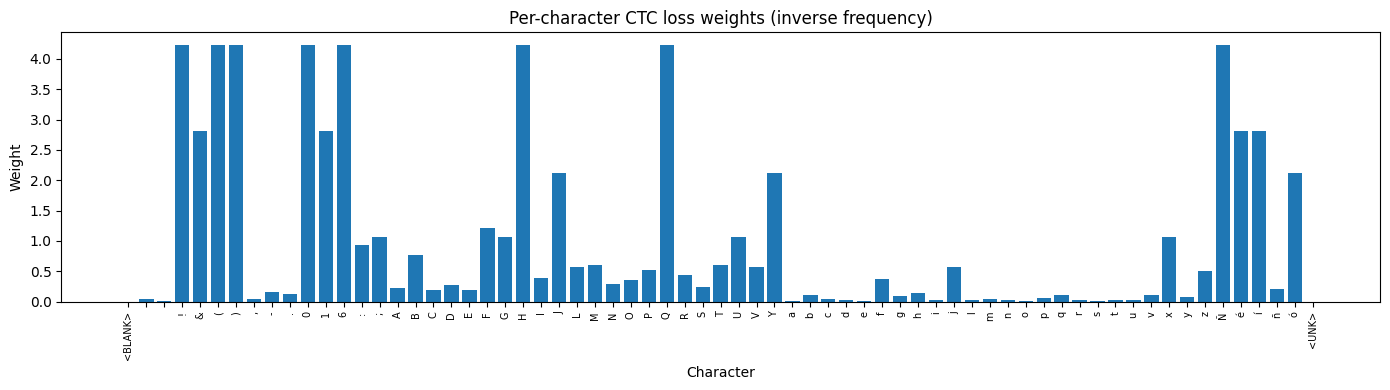

In [9]:
# Visualise the full weight distribution
chars = [ch for ch, _ in sorted(vocab.items(), key=lambda kv: kv[1])]
weight_vals = [weights[vocab[ch]].item() for ch in chars]

plt.figure(figsize=(14, 4))
plt.bar(range(len(chars)), weight_vals)
plt.xticks(range(len(chars)), chars, fontsize=7, rotation=90)
plt.title('Per-character CTC loss weights (inverse frequency)')
plt.ylabel('Weight')
plt.xlabel('Character')
plt.tight_layout()
plt.show()


## 2. Inspect the CRNN architecture

The model maps an image of shape `(B, 1, H, W)` through:
1. **CNN backbone** – four conv-BN-LeakyReLU-MaxPool blocks that collapse the height to 1
2. **BiLSTM** – two layers treating width positions as time steps
3. **Linear projection** – maps to log-probabilities over vocabulary


In [10]:
model = CRNN(num_classes=len(vocab))
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(model)

# Smoke test: forward pass on random input
x = torch.randn(2, 1, 32, 256)
out = model(x)
print(f'\nInput shape:  {tuple(x.shape)}')
print(f'Output shape: {tuple(out.shape)}  (T, B, num_classes)')


Total parameters: 4,739,075
CRNN(
  (cnn): CNNBackbone(
    (blocks): Sequential(
      (0): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      )
      (1): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      )
      (2): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine

## 3. Run training

The training script handles dataset loading, batching, and saving the best checkpoint.
Run it from the project root in a terminal:

```bash
python scripts/train_crnn.py \
    --ground-truth-file data/ground_truth/ground_truth.jsonl \
    --line-image-dir data/crops \
    --output-dir outputs/crnn \
    --epochs 30
```

Or call it directly from this notebook (blocking):


In [11]:
import subprocess, sys
result = subprocess.run(
    [
        sys.executable, str(ROOT / 'scripts' / 'train_crnn.py'),
        '--ground-truth-file', str(GROUND_TRUTH_FILE),
        '--line-image-dir', str(CROP_DIR),
        '--output-dir', str(OUTPUT_DIR),
        '--epochs', '30',
    ],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)


Device: cpu
Vocabulary size: 67 characters → /Users/ray/CNN-RNN/outputs/crnn/crnn_vocab.json
Dataset size: 5 samples
Epoch   1/30  loss=0.0000
Epoch   2/30  loss=0.0000
Epoch   3/30  loss=0.0000
Epoch   4/30  loss=0.0000
Epoch   5/30  loss=0.0000
Epoch   6/30  loss=0.0000
Epoch   7/30  loss=0.0000
Epoch   8/30  loss=0.0000
Epoch   9/30  loss=0.0000
Epoch  10/30  loss=0.0000
Epoch  11/30  loss=0.0000
Epoch  12/30  loss=0.0000
Epoch  13/30  loss=0.0000
Epoch  14/30  loss=0.0000
Epoch  15/30  loss=0.0000
Epoch  16/30  loss=0.0000
Epoch  17/30  loss=0.0000
Epoch  18/30  loss=0.0000
Epoch  19/30  loss=0.0000
Epoch  20/30  loss=0.0000
Epoch  21/30  loss=0.0000
Epoch  22/30  loss=0.0000
Epoch  23/30  loss=0.0000
Epoch  24/30  loss=0.0000
Epoch  25/30  loss=0.0000
Epoch  26/30  loss=0.0000
Epoch  27/30  loss=0.0000
Epoch  28/30  loss=0.0000
Epoch  29/30  loss=0.0000
Epoch  30/30  loss=0.0000

Training complete.  Best loss: 0.0000
Checkpoint saved to: /Users/ray/CNN-RNN/outputs/crnn/crnn_checkp

## 4. Inference with the trained CRNN

Once training is complete, load the checkpoint and run a quick inference check.


In [12]:
from src.crnn_model import CRNNOCRModel
from src.utils import CRNNConfig
from PIL import Image

checkpoint_path = OUTPUT_DIR / 'crnn_checkpoint.pt'
vocab_path = OUTPUT_DIR / 'crnn_vocab.json'

if checkpoint_path.exists() and vocab_path.exists():
    crnn = CRNNOCRModel(CRNNConfig(
        checkpoint_path=str(checkpoint_path),
        vocab_path=str(vocab_path),
    ))
    # Run on first available crop
    crop_paths = sorted(CROP_DIR.glob('*_crop.png'))
    if crop_paths:
        img = Image.open(crop_paths[0]).convert('L')
        text = crnn.predict_page_text([img])
        print(f'Page: {crop_paths[0].name}')
        print('CRNN output:')
        print(text[:500])
else:
    print('No checkpoint found. Run training first.')


Page: buendia_instruccion_page_0001_crop.png
CRNN output:
sj
